# Ex1

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
df = pd.read_csv("data1.csv")
X, y = df.drop(columns=['y']), df[['y']]

X_norm = (X - X.mean()) / X.std()
print(type(X), type(y))
print(X.shape, y.shape)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>
(100, 2) (100, 1)


## Mean, std, min, max, quantile

In [91]:
df.describe()

,x1,x2,y
count,100.000000,100.000000,100.000000
mean,-16.516452,194.787410,-187.672542
std,251.828994,114.163784,299.078952
min,-589.775534,6.635132,-916.994934
25%,-90.396867,90.159514,-325.494505
50%,-0.975545,199.571187,-158.721861
75%,89.149205,294.257264,-41.646005
max,558.750000,394.754775,805.000000


### x1
- Widać, że zmienne dla $x1$ rozkładają się równomiernie, widzimy to po kwantylach
- Zmienne są bardzo rozproszone, ponieważ odchylenie standardowe wynosi ok $252$
### x2 
- średnia jest bliska medianie, zatem nie ma dużo anomali
- odchylenie standardowe też jest duże, ale o wiele miejsze niż w x1

## Seaborn plots

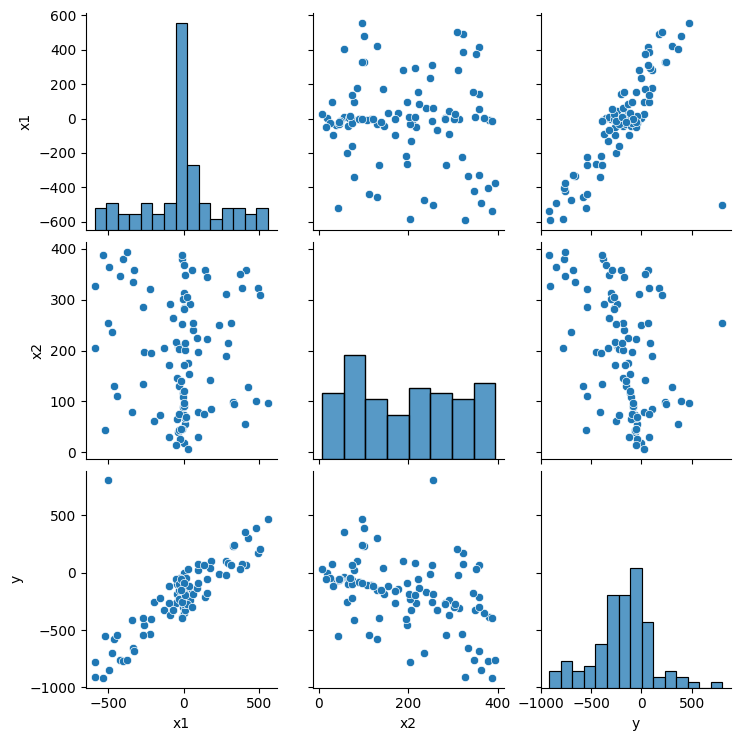

In [92]:
import seaborn as sns
sns.pairplot(df)

<Axes: >

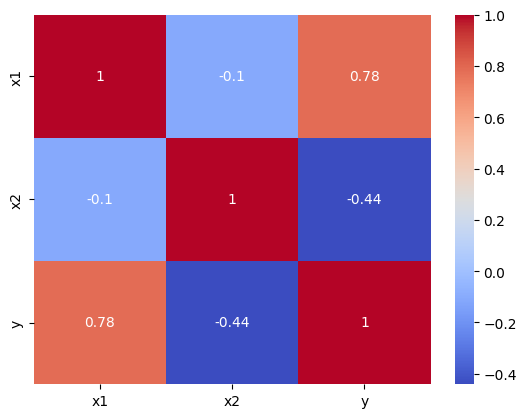

In [93]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

1. Po tych wykresach widać, że x1 i x2 nie są liniowozależne
2. Między x1 a y jest zależność liniowa
3. Między x2 a y nie ma zależności liniowej


**Czy regresja liniowa jest modelem odpowiednim dla danych data1.csv? Jak odpowiednio przygotować dane do modelowania?**
- Wydaje mi się, że w bazowym stanie nie, ponieważ pojawiają się outliery

## preprocess data

In [94]:
def preprocess_data(x_train: pd.DataFrame, y_train: pd.DataFrame):
    p = 0.98

    mask = (
        (x_train["x1"] <= x_train["x1"].quantile(p))
        & (x_train["x2"] <= x_train["x2"].quantile(p))
        & (y_train['y'] <= y_train['y'].quantile(p))
    )

    x_reduced, y_reduced = x_train[mask], y_train[mask]

    return x_reduced, y_reduced

# Ex2

In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [141]:
df = pd.read_csv("data1.csv")
X, y = df.drop(columns=['y']), df[['y']]
print(type(X), type(y))
print(X.shape, y.shape)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>
(100, 2) (100, 1)


In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_red, y_train_red = preprocess_data(X_train, y_train)

**Pytanie - Czy będzie on taki sam przy budowanie pojedynczego modelu jak również w sytuacji, kiedy chcemy wybrać jeden spośród kilku modeli?**
- Tak, bo jeśli chcemy porównać do siebie różne modele, to muszą być trenowane na tym samym zbiorze treningowym, ponieważ jeśli model A i model B uczą się na innych danych, to trudno stwierdzić, który jest lepszy, bo może różnica wynikać z danych, a nie z modelu.

In [143]:
import sklearn.metrics as skm
def model_train_eval(X_train, y_train, X_test_, y_test_, model = LinearRegression(fit_intercept=True), variant="None"):
    model.fit(X_train, y_train)
    
    # print(model.__class__.__name__)
    if model.__class__.__name__ == "LinearRegression":
        print(variant, model.coef_)

    y_pred = model.predict(X_test_)
    rsc = model.score(X_test_, y_test_)
    mse = skm.mean_squared_error(y_test_, y_pred)
    mape = skm.mean_absolute_percentage_error(y_test, y_pred)
    mae = skm.mean_absolute_error(y_test, y_pred)

    return dict(variant=variant, MSE=mse, MAE=mae, MAPE=mape, Rsq=rsc)

In [144]:
from sklearn.dummy import DummyRegressor
all_results = []
all_results.append(model_train_eval(X_train, y_train, X_test, y_test, variant="Linear Regression: raw data"))
all_results.append(model_train_eval(X_train_red, y_train_red, X_test, y_test, variant="Linear Regression: preprocessed data"))

dummy_model = DummyRegressor(strategy='mean')
all_results.append(model_train_eval(X_train, y_train, X_test, y_test, model = dummy_model, variant="Dummy model: raw data"))
all_results.append(model_train_eval(X_train_red, y_train_red, X_test, y_test, model = dummy_model, variant="Dummy model: preprocessed data"))


pd.DataFrame(all_results)

Linear Regression: raw data [[ 0.86602687 -0.93133305]]
Linear Regression: preprocessed data [[ 1.00052736 -0.99840741]]


,variant,MSE,MAE,MAPE,Rsq
0,Linear Regression: raw data,1043.043946,26.221601,0.119939,0.984534
1,Linear Regression: preprocessed data,0.722289,0.744987,0.006883,0.999989
2,Dummy model: raw data,70092.425271,206.031212,1.450612,-0.039327
3,Dummy model: preprocessed data,72739.660930,208.160974,1.574394,-0.078580


# Ex3

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [146]:
df = pd.read_csv("advertising.csv")
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


1. odchylenia standardowe nie są duże
2. dane są nawet równomiernie rozłożone, po za max(Newspaper)

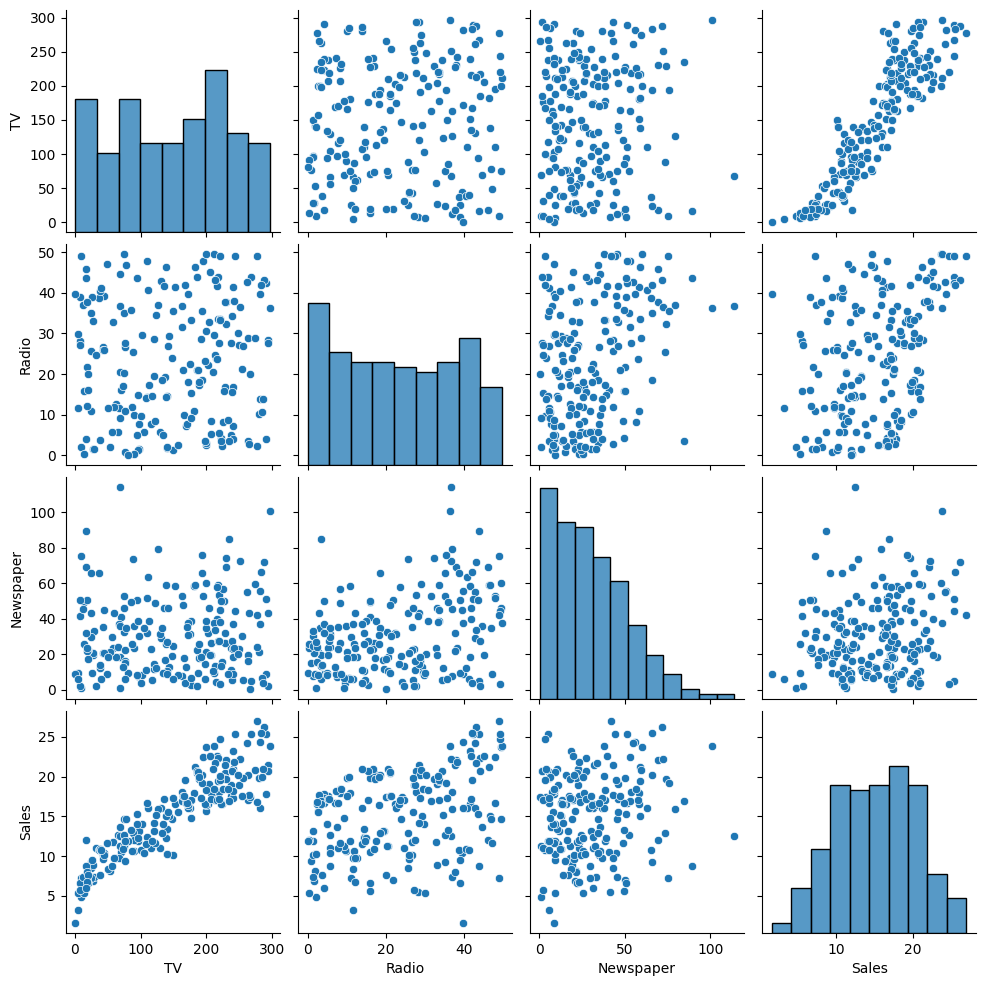

In [147]:
import seaborn as sns
sns.pairplot(df)

<Axes: >

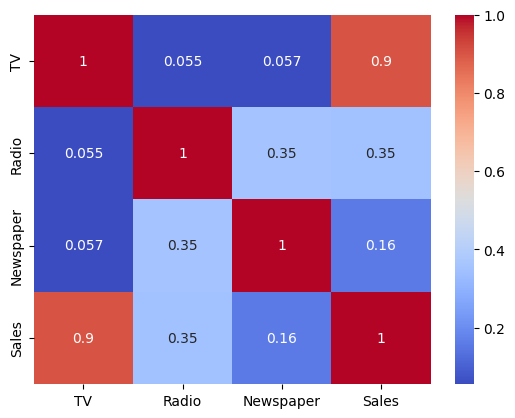

In [148]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [149]:
df.head()

X, y = df.drop(columns = ['Sales']), df[['Sales']]
X_norm = (X - X.mean(axis=0)) / X.std(axis=0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2137)
X_train_norm, X_test_norm = train_test_split(X_norm, test_size=0.2, random_state=2137)

In [150]:
import sklearn.metrics as skm
from sklearn.linear_model import LinearRegression

def model_train_eval(
    X_train,
    y_train,
    X_test_,
    y_test_,
    variant="None",
):
    model=LinearRegression(fit_intercept=True)
    model.fit(X_train, y_train)
    
    print(variant, model.coef_)

    y_pred = model.predict(X_test_)
    rsc = model.score(X_test_, y_test_)
    mse = skm.mean_squared_error(y_test_, y_pred)
    mape = skm.mean_absolute_percentage_error(y_test_, y_pred)
    mae = skm.mean_absolute_error(y_test_, y_pred)

    return dict(variant=variant, MSE=mse, MAE=mae, MAPE=mape, Rsq=rsc)

all_results = []
all_results.append(model_train_eval(X_train, y_train, X_test, y_test, variant="Linear Regression: raw data"))
all_results.append(model_train_eval(X_train_norm, y_train, X_test_norm, y_test, variant="Linear Regression: after normalization"))

pd.DataFrame(all_results)

Linear Regression: raw data [[0.05442617 0.11520582 0.00105471]]
Linear Regression: after normalization [[4.67271722 1.71043887 0.02297018]]


,variant,MSE,MAE,MAPE,Rsq
0,Linear Regression: raw data,3.121882,1.428977,0.106536,0.868076
1,Linear Regression: after normalization,3.121882,1.428977,0.106536,0.868076


### Wnioski
- Przed normalizacją mogłoby się wydawać, że pierwsza waga jest najmniej ważna
- Ale przez różnicę w skali w tym featerze dostajemy błędną przesłankę
- Po normalizacji widzimy, że ten czynnik miał największy wpływ na wynik